
<a id="summary"></a>

## Notebook 2 — Transactions EDA & monthly aggregates (`transactions_raw`)

**v2.** This notebook builds **`df_tx`** at **transaction month** grain (completed transactions only), runs **calendar-time EDA**, and answers roadmap questions **Q2–Q5** with **M3 + M6** cohort KPIs.

### How this notebook is organized

**Jump to parts:** [Part 1 — data loading & joins](#part-1) · [Part 2 — monthly aggregates & calendar-time EDA](#part-2) · [Part 3 — cohort analysis](#part-3)

**Part 1 — data loading & joins**

1. [Load `customers_raw` and `transactions_raw`](#q1)
2. [Join transactions to customer attributes](#q2)
3. [Transaction month buckets](#q3)

**Part 2 — monthly aggregates & calendar-time EDA**

4. [Transactions per month](#Transactions-per-month)
5. [Total amount per month](#Total-amount-per-month)
6. [Unique users over time](#Unique-users-over-time)
7. [Total amount per channel](#Total-amount-per-channel)

**Part 3 — cohort analysis (M3 + M6 retention)**

8. [Which acquisition month produces the most retained customers?](#bq2)
9. [At what month do most customers disengage?](#bq3)
10. [Are recent cohorts healthier than older ones?](#bq4)
11. [Which acquisition channel brings the highest quality customers?](#bq5)

---

### Objectives

- **Achieved:** Build **`df_tx`** joined to customer attributes (**acquisition channel**, **segment**, **registration date**), using **completed** transactions only.
- **Achieved:** Answer **Q2–Q5** with **M3 + M6** cohort KPIs, a **tenure retention curve (M0..M6)**, and **channel-quality ranking** (M6-first).
- **Deferred:** RFM, LTV, segment behavioral profiles, and predictive churn (later notebooks).

### Business Questions (from the project roadmap)

2. Which acquisition month produces the most retained customers?
3. At what month do most customers disengage?
4. Are recent cohorts healthier than older ones?
5. Which acquisition channel brings the highest quality customers?

### Expected output

- `df_tx` joined dataset (transactions + customer attributes, transaction month).
- Monthly counts / amount / MAU / channel mix for calendar-time EDA.
- Cohort outputs (overall + by `acquisition_channel`):
  - **M3 + M6 active rates**
  - **Strict streak (M0..M3, M0..M6)**
  - **Tenure retention curve (M0..M6) + drop-off window**
  - Rankings for best cohort months (quality vs volume) and best acquisition channels (M6-first).


In [60]:

# ── Importing libraries ──────────────────────────────────────────────────────

import os

import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter

from IPython.display import display

sns.set_theme(style="whitegrid")


def format_brl_value(value):
    formatted = f"{value:,.2f}".replace(",", "_").replace(".", ",").replace("_", ".")
    return f"R$ {formatted}"


def format_brl(value, pos):
    return format_brl_value(value)



<a id="part-1"></a>

## Part 1 — Data loading & joins

**Goal:** pull **`customers_raw`** and **`transactions_raw`** (completed only) from Supabase, merge them into **`df_tx`**, and construct **`transaction_month`** for monthly aggregates.

[↑ Back to summary](#summary)



<a id="q1"></a>

### 1. Load `customers_raw` and `transactions_raw` from Supabase

[↑ Back to summary](#summary)


In [74]:

# override=True ensures .env changes are picked up without restarting the kernel
load_dotenv(override=True)

DATABASE_URL = os.environ["SUPABASE_DATABASE_URL"]

engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,  # helps avoid stale connections in notebooks
)

sql_customers = text(
    "SELECT\n"
    "  customer_id,\n"
    "  acquisition_channel,\n"
    "  acquisition_cost,\n"
    "  registration_date,\n"
    "  true_segment\n"
    "FROM public.customers_raw\n"
)

df_customers = pd.read_sql(sql_customers, engine)

sql_transactions = text(
    "SELECT\n"
    "  transaction_id,\n"
    "  customer_id,\n"
    "  transaction_datetime,\n"
    "  amount,\n"
    "  channel,\n"
    "  status\n"
    "FROM public.transactions_raw\n"
    "WHERE status = 'completed'\n"
)

df_transactions = pd.read_sql(sql_transactions, engine)

display(df_customers.head())
display(df_transactions.head())
print("df_customers:", df_customers.shape)
print("df_transactions (completed):", df_transactions.shape)


,customer_id,acquisition_channel,acquisition_cost,registration_date,true_segment
0,f09a236e-df30-4a65-bee2-06f8a92bda08,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active
1,2b5081da-f193-4fbe-b553-6b604117780b,paid_ads,222.02,2023-09-30 00:00:00+00:00,high_value_active
2,26be2f5d-31da-4734-9be3-b2d6e4884f44,referral,39.81,2022-09-22 00:00:00+00:00,high_value_active
3,cdf790dc-e1f8-41e6-b3d1-940aa4c02868,referral,52.54,2023-05-06 00:00:00+00:00,high_value_active
4,895aaa97-46a4-4fe6-92dc-1cbc73d4cc86,paid_ads,199.99,2023-10-16 00:00:00+00:00,high_value_active


,transaction_id,customer_id,transaction_datetime,amount,channel,status
0,36ded55f-71f8-4158-9326-cd43b372909c,f09a236e-df30-4a65-bee2-06f8a92bda08,2023-06-23 03:24:00+00:00,229.31,online,completed
1,d0b493b6-8c1e-48a8-b87f-1442a85a395b,f09a236e-df30-4a65-bee2-06f8a92bda08,2023-06-23 05:05:00+00:00,197.42,in_app,completed
2,caf222d4-a260-4214-9c2d-96523054df3a,f09a236e-df30-4a65-bee2-06f8a92bda08,2023-06-24 10:12:00+00:00,163.86,in_app,completed
3,8458104f-d32a-4cd0-9ed8-9147cc065743,f09a236e-df30-4a65-bee2-06f8a92bda08,2023-06-30 14:45:00+00:00,200.62,online,completed
4,8f38a96c-be53-46b9-9ad9-96e283d36798,f09a236e-df30-4a65-bee2-06f8a92bda08,2023-06-28 16:34:00+00:00,177.76,online,completed


df_customers: (8000, 5)
df_transactions (completed): (2041965, 6)



<a id="q2"></a>

### 2. Join transactions to customer attributes

`df_transactions` is merged with `df_customers` on **`customer_id`** (inner join) so every row carries **`acquisition_channel`**, **`true_segment`**, and **`registration_date`** for cohort and channel analyses.

[↑ Back to summary](#summary)


In [75]:
# Join transactions to customer attributes
df_tx = df_transactions.merge(df_customers, on="customer_id", how="inner")


<a id="q3"></a>

### 3. Transaction month buckets

We normalize **`transaction_datetime`** and **`registration_date`** to month-start timestamps, then ensure **`amount`** is numeric. This grain powers monthly EDA and cohort eligibility.

[↑ Back to summary](#summary)


In [76]:

# Transaction month (calendar month start)
tx_dt = df_tx["transaction_datetime"]
if isinstance(tx_dt.dtype, pd.DatetimeTZDtype):
    tx_dt = tx_dt.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["transaction_month"] = tx_dt.dt.to_period("M").dt.to_timestamp()

# Registration month (cohort month anchor)
reg = df_tx["registration_date"]
if isinstance(reg.dtype, pd.DatetimeTZDtype):
    reg = reg.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["registration_month"] = reg.dt.to_period("M").dt.to_timestamp()

# Amount numeric
df_tx["amount"] = pd.to_numeric(df_tx["amount"], errors="coerce")

# Drop the trailing calendar month if we don't yet have enough intra-month coverage.
# Rule: keep the latest month only if `transaction_datetime` includes activity on
# at least 20 distinct calendar days within that month (days 1–20+).
MIN_DISTINCT_DAYS_IN_LATEST_MONTH = 20

_tx_dt_guard = df_tx["transaction_datetime"]
if isinstance(_tx_dt_guard.dtype, pd.DatetimeTZDtype):
    _tx_dt_guard = _tx_dt_guard.dt.tz_convert("UTC").dt.tz_localize(None)

last_month_period = _tx_dt_guard.dt.to_period("M").max()
last_month_mask = _tx_dt_guard.dt.to_period("M") == last_month_period

distinct_days = _tx_dt_guard.loc[last_month_mask].dt.day.nunique()

days_in_month = last_month_period.days_in_month if pd.notna(last_month_period) else None
threshold = min(MIN_DISTINCT_DAYS_IN_LATEST_MONTH, days_in_month) if days_in_month is not None else MIN_DISTINCT_DAYS_IN_LATEST_MONTH

if pd.notna(last_month_period) and distinct_days < threshold:
    print(
        f"Dropping latest month {last_month_period} from df_tx: "
        f"only {distinct_days} distinct day(s) observed (threshold={threshold} of {days_in_month} days in month)."
    )
    df_tx = df_tx.loc[~last_month_mask].copy()
else:
    print(
        f"Keeping latest month {last_month_period}: "
        f"{distinct_days} distinct day(s) observed (threshold={threshold} of {days_in_month} days in month)."
    )

# Keep derived month columns consistent after potential row drops
_tx_dt2 = df_tx["transaction_datetime"]
if isinstance(_tx_dt2.dtype, pd.DatetimeTZDtype):
    _tx_dt2 = _tx_dt2.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["transaction_month"] = _tx_dt2.dt.to_period("M").dt.to_timestamp()

_reg2 = df_tx["registration_date"]
if isinstance(_reg2.dtype, pd.DatetimeTZDtype):
    _reg2 = _reg2.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["registration_month"] = _reg2.dt.to_period("M").dt.to_timestamp()

print("df_tx (joined):", df_tx.shape)
display(df_tx.head())

# Latest complete calendar month observed in completed transactions
latest_complete_month = df_tx["transaction_month"].max().to_period("M")
print("latest_complete_month:", latest_complete_month)


Keeping latest month 2026-02: 28 distinct day(s) observed (threshold=20 of 28 days in month).
df_tx (joined): (2041965, 12)


,transaction_id,customer_id,transaction_datetime,amount,channel,status,acquisition_channel,acquisition_cost,registration_date,true_segment,transaction_month,registration_month
0,36ded55f-71f8-4158-9326-cd43b372909c,f09a236e-df30-4a65-bee2-06f8a92bda08,2023-06-23 03:24:00+00:00,229.31,online,completed,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2023-06-01,2023-06-01
1,d0b493b6-8c1e-48a8-b87f-1442a85a395b,f09a236e-df30-4a65-bee2-06f8a92bda08,2023-06-23 05:05:00+00:00,197.42,in_app,completed,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2023-06-01,2023-06-01
2,caf222d4-a260-4214-9c2d-96523054df3a,f09a236e-df30-4a65-bee2-06f8a92bda08,2023-06-24 10:12:00+00:00,163.86,in_app,completed,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2023-06-01,2023-06-01
3,8458104f-d32a-4cd0-9ed8-9147cc065743,f09a236e-df30-4a65-bee2-06f8a92bda08,2023-06-30 14:45:00+00:00,200.62,online,completed,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2023-06-01,2023-06-01
4,8f38a96c-be53-46b9-9ad9-96e283d36798,f09a236e-df30-4a65-bee2-06f8a92bda08,2023-06-28 16:34:00+00:00,177.76,online,completed,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2023-06-01,2023-06-01


latest_complete_month: 2026-02



<a id="part-2"></a>

## Part 2 — Monthly aggregates & calendar-time EDA

**Goal:** summarize **calendar-time** behavior (counts, TPV, MAU, channel mix) to contextualize cohort findings.

[↑ Back to summary](#summary)



<a id="Transactions-per-month"></a>

### 4. Transactions per month

[↑ Back to summary](#summary)


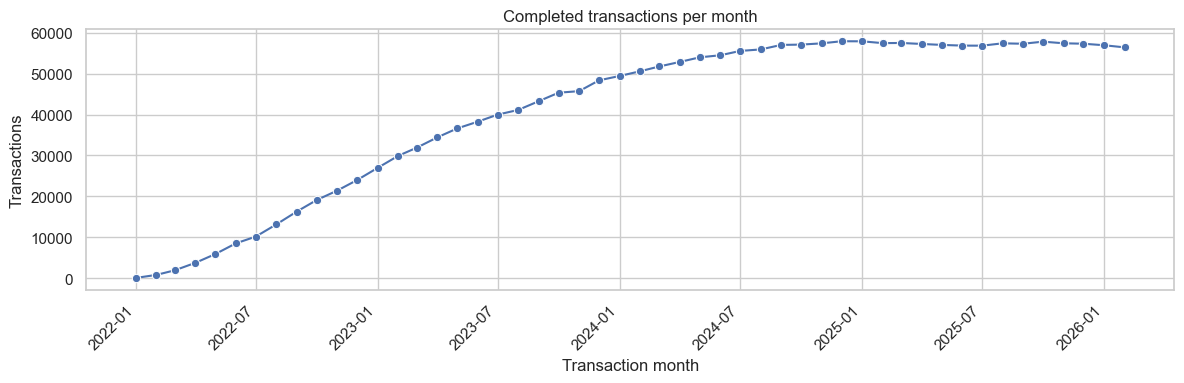

In [77]:
tx_per_month = (
    df_tx.groupby("transaction_month", as_index=False)
    .size()
    .rename(columns={"size": "tx_count"})
    .sort_values("transaction_month")
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=tx_per_month, x="transaction_month", y="tx_count", marker="o", ax=ax)
ax.set_title("Completed transactions per month")
ax.set_xlabel("Transaction month")
ax.set_ylabel("Transactions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Completed transaction volume shows a multi-quarter expansion from near-zero in early 2024 to a peak around ~135–140k tx/month in early 2026, with the steepest acceleration in late 2025—a pattern consistent with scaling usage (more customers and/or higher monthly activity).



<a id="Total-amount-per-month"></a>

### 5. Total amount per month

[↑ Back to summary](#summary)


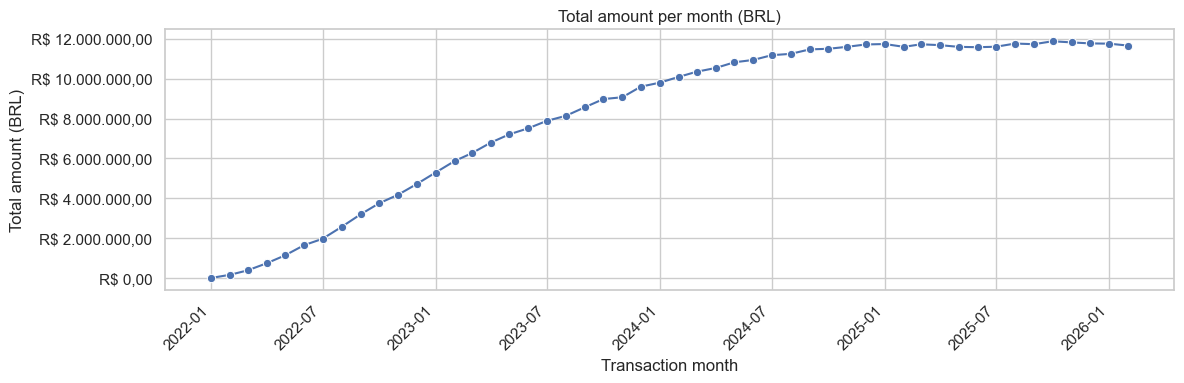

In [78]:

amount_per_month = (
    df_tx.groupby("transaction_month", as_index=False)["amount"]
    .sum()
    .rename(columns={"amount": "total_amount"})
    .sort_values("transaction_month")
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=amount_per_month, x="transaction_month", y="total_amount", marker="o", ax=ax)
ax.set_title("Total amount per month (BRL)")
ax.set_xlabel("Transaction month")
ax.set_ylabel("Total amount (BRL)")
ax.yaxis.set_major_formatter(FuncFormatter(format_brl))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Monthly TPV ramps from near-zero in early 2024 to roughly **R$25–27M** by **Jan–Feb 2026**, with the steepest acceleration through **late 2025**—consistent with **scaling throughput** (more active customers and/or higher spend per active user) on **completed** transactions.



<a id="Unique-users-over-time"></a>

### 6. Unique users over time (MAU)

[↑ Back to summary](#summary)


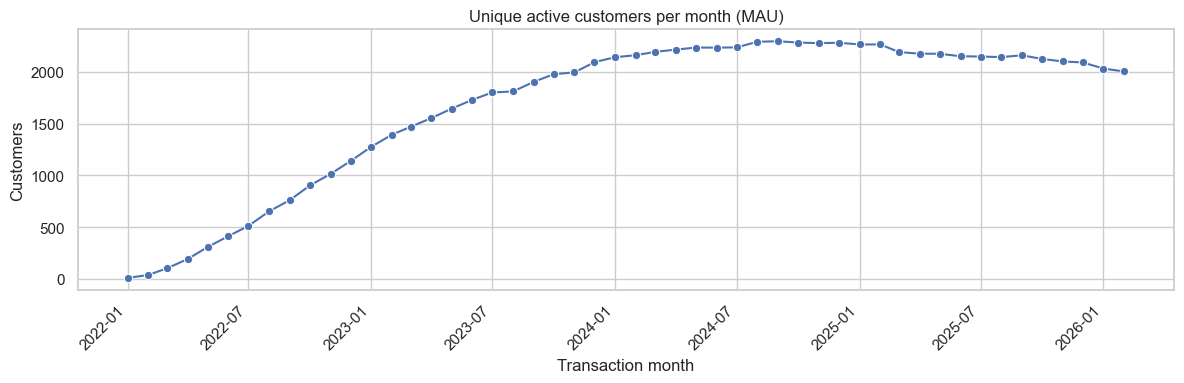

In [79]:

mau_per_month = (
    df_tx.groupby("transaction_month", as_index=False)["customer_id"]
    .nunique()
    .rename(columns={"customer_id": "mau"})
    .sort_values("transaction_month")
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=mau_per_month, x="transaction_month", y="mau", marker="o", ax=ax)
ax.set_title("Unique active customers per month (MAU)")
ax.set_xlabel("Transaction month")
ax.set_ylabel("Customers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


MAU shows a similar pattern to TPV, with a sharp increase in late 2025.


<a id="Total-amount-per-channel"></a>

### 7. Total amount per channel over time (stacked)

[↑ Back to summary](#summary)


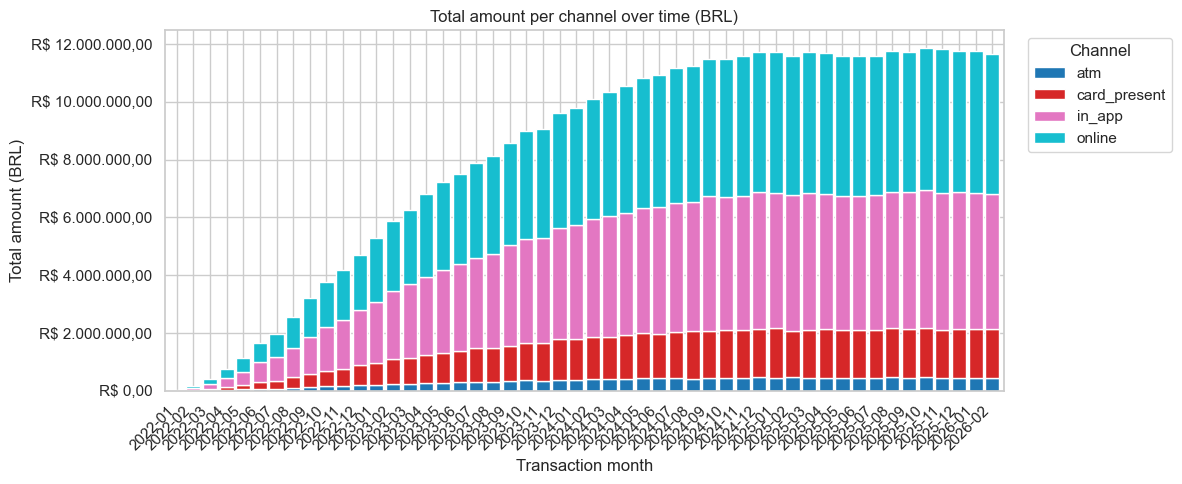

In [81]:

amount_pivot = (
    df_tx.pivot_table(
        index="transaction_month",
        columns="channel",
        values="amount",
        aggfunc="sum",
        fill_value=0,
    )
    .sort_index()
)

# Use categorical month labels for the x-axis (avoids pandas datetime/period plotting edge cases)
amount_pivot = amount_pivot.copy()
if isinstance(amount_pivot.index, pd.PeriodIndex):
    amount_pivot.index = amount_pivot.index.strftime("%Y-%m")
elif isinstance(amount_pivot.index, pd.DatetimeIndex):
    amount_pivot.index = amount_pivot.index.strftime("%Y-%m")
elif pd.api.types.is_period_dtype(amount_pivot.index):
    amount_pivot.index = pd.PeriodIndex(amount_pivot.index, freq="M").strftime("%Y-%m")
elif pd.api.types.is_datetime64_any_dtype(amount_pivot.index):
    amount_pivot.index = pd.to_datetime(amount_pivot.index).strftime("%Y-%m")
else:
    amount_pivot.index = amount_pivot.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
amount_pivot.plot(kind="bar", stacked=True, ax=ax, width=0.85, colormap="tab10")
ax.set_title("Total amount per channel over time (BRL)")
ax.set_xlabel("Transaction month")
ax.set_ylabel("Total amount (BRL)")
ax.yaxis.set_major_formatter(FuncFormatter(format_brl))
ax.legend(title="Channel", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Chart read — Total amount per channel over time (BRL, stacked):** Monthly payment volume scales from a low base in early 2024 to **>R$25M** by early 2026, with the slope steepening from **mid‑2025 onward**—a pattern that usually reflects a mix of **user-base growth** and **higher monthly throughput per active customer** (more frequent spend and/or larger tickets), not just a one-off spike.

**Channel mix story:** **`in_app` drives most of the incremental dollars** and becomes the dominant stack by the end of the window—consistent with a product-led, mobile-first payments experience where the app is the primary capture point. **`card_present`** and **`online`** grow materially and form the “middle stack,” suggesting omnichannel usage (physical + web) scales alongside the core app. **`atm`** remains a thin layer: it may grow slightly in absolute terms, but its **share of total volume declines** over time, which is typical when digital rails carry the scaling load.

Prioritize roadmap and risk controls on **`in_app` reliability, limits, fraud, and UX conversion** (that’s where volume leverage is highest). Treat **`card_present` / `online`** as important secondary surfaces for acquisition and high-ticket flows. Keep **`atm`** as a niche/edge channel unless strategy explicitly targets cash access use cases.



<a id="part-3"></a>

## Part 3 — Cohort analysis (M3 + M6 retention by registration month)

**Goal:** measure **retention quality** at **M3** and **M6** by **`cohort_month`** and **`acquisition_channel`**, using the **full customer roster** and completed transaction activity only.

[↑ Back to summary](#summary)



We compare eligible **cohort months** using **cohort size** and retention KPIs at **M3** and **M6**—each cohort is a registration (acquisition) month.

We measure retention by **cohort month**: `cohort_month` is `registration_date` truncated to month start. **M0** is the registration month; **M1..M6** are subsequent calendar months (tenure slots).

A customer is **active** in a slot if they have at least one **completed** transaction in that calendar month.

**KPIs used in this section**

- **`m3_active_rate` / `m6_active_rate`:** share of cohort members active in M3 / M6.
- **`strict_streak_m3_rate`:** share active in all of M0..M3.
- **`strict_streak_m6_rate`:** share active in all of M0..M6.

**Eligibility:** each KPI uses its own observable denominator. A customer enters M3 metrics only if `cohort_month + 3 months <= latest_complete_month`; similarly for M6 with `+ 6 months`.

**Design choices:** (1) The cohort roster comes from **`df_customers`** (all customers), not from **`df_tx`**. The latter is an inner join on completed transactions, so customers with zero completed transactions would disappear from denominators if cohorts came only from `df_tx`. (2) We detect activity by **absence vs presence**: each row in `df_tx` is a real completed transaction, so inactive months do not appear. We build a **customer × M0..M6** expected grid and **left-join** observed transaction months; no match means inactive for that month.


In [82]:

# Full cohort roster from all customers; observed active months from completed tx only
reg = df_customers["registration_date"]
if isinstance(reg.dtype, pd.DatetimeTZDtype):
    reg = reg.dt.tz_convert("UTC").dt.tz_localize(None)

customers = df_customers[["customer_id", "acquisition_channel"]].copy()
customers["cohort_month"] = reg.dt.to_period("M").dt.to_timestamp()

actual_active = (
    df_tx.groupby(["customer_id", "transaction_month"])
    .size()
    .reset_index(name="tx_count")
    .rename(columns={"transaction_month": "calendar_month"})
    .assign(has_tx=True)[["customer_id", "calendar_month", "has_tx"]]
)


In [83]:

# Parameter block for retention horizons
RETENTION_HORIZONS = [3, 6]
MAX_TENURE = max(RETENTION_HORIZONS)

# Latest complete calendar month observed in transaction data
latest_complete_month = df_tx["transaction_month"].max().to_period("M")

# Expected M0..M6 grid: cross-product of customers × tenure slots, left-join
# observed activity, pivot to one row per customer with m0..m6 booleans.
tenure_df = pd.DataFrame({"tenure_index": list(range(MAX_TENURE + 1))})
cust_for_grid = customers.copy()
cust_for_grid["_key"] = 1
tenure_df["_key"] = 1
grid = cust_for_grid.merge(tenure_df, on="_key").drop(columns="_key")

# Expected calendar month for each slot (normalized to first-of-month)
grid["calendar_month"] = grid.apply(
    lambda r: r["cohort_month"] + pd.DateOffset(months=int(r["tenure_index"])),
    axis=1,
)
grid["calendar_month"] = grid["calendar_month"].dt.to_period("M").dt.to_timestamp()

# Left join: no match means no completed transaction in that month
grid = grid.merge(actual_active, on=["customer_id", "calendar_month"], how="left")
grid["has_tx"] = grid["has_tx"].fillna(False)

pivot = grid.pivot_table(
    index=["customer_id", "cohort_month", "acquisition_channel"],
    columns="tenure_index",
    values="has_tx",
    aggfunc="max",
    fill_value=False,
).reset_index()
pivot.columns.name = None

# Normalize dynamic tenure columns to m0..m6 names
rename_map = {i: f"m{i}" for i in range(MAX_TENURE + 1)}
pivot = pivot.rename(columns=rename_map)
for i in range(MAX_TENURE + 1):
    col = f"m{i}"
    if col not in pivot.columns:
        pivot[col] = False

# Horizon-specific eligibility masks (per customer)
for h in RETENTION_HORIZONS:
    h_month = (pivot["cohort_month"] + pd.DateOffset(months=h)).dt.to_period("M")
    pivot[f"eligible_h{h}"] = h_month <= latest_complete_month

# Horizon-specific strict streak flags
pivot["strict_streak_m3"] = pivot[["m0", "m1", "m2", "m3"]].all(axis=1)
pivot["strict_streak_m6"] = pivot[[f"m{i}" for i in range(7)]].all(axis=1)

pivot.head()


,customer_id,cohort_month,acquisition_channel,m0,m1,m2,m3,m4,m5,m6,eligible_h3,eligible_h6,strict_streak_m3,strict_streak_m6
0,000012e2-62df-4348-adab-ecee5fa1170f,2022-05-01,paid_ads,True,True,False,False,True,True,False,True,True,False,False
1,000a5ed6-589c-48dc-adf3-2799fbd812d9,2022-11-01,paid_ads,False,False,False,False,False,False,False,True,True,False,False
2,000b504b-2798-4b18-a3da-15179c2f6152,2023-05-01,partnership,False,False,False,False,False,False,False,True,True,False,False
3,000fccc1-6018-403e-bfc9-bc93fede6c32,2022-01-01,partnership,False,True,True,True,True,True,True,True,True,False,False
4,0013b1ca-b35a-40a7-b7a1-0fb91bcd4cdb,2023-05-01,referral,False,True,True,False,False,False,False,True,True,False,False


In [84]:

# Cohort KPI table with horizon-specific denominators
agg_rows = []
for cohort_month, g in pivot.groupby("cohort_month"):
    row = {"cohort_month": cohort_month}

    g3 = g[g["eligible_h3"]]
    row["eligible_n_h3"] = int(len(g3))
    row["m3_active_count"] = int(g3["m3"].sum())
    row["strict_streak_m3_count"] = int(g3["strict_streak_m3"].sum())
    row["m3_active_rate"] = row["m3_active_count"] / row["eligible_n_h3"] if row["eligible_n_h3"] else np.nan
    row["strict_streak_m3_rate"] = (
        row["strict_streak_m3_count"] / row["eligible_n_h3"] if row["eligible_n_h3"] else np.nan
    )

    g6 = g[g["eligible_h6"]]
    row["eligible_n_h6"] = int(len(g6))
    row["m6_active_count"] = int(g6["m6"].sum())
    row["strict_streak_m6_count"] = int(g6["strict_streak_m6"].sum())
    row["m6_active_rate"] = row["m6_active_count"] / row["eligible_n_h6"] if row["eligible_n_h6"] else np.nan
    row["strict_streak_m6_rate"] = (
        row["strict_streak_m6_count"] / row["eligible_n_h6"] if row["eligible_n_h6"] else np.nan
    )

    agg_rows.append(row)

cohort_kpi = pd.DataFrame(agg_rows).sort_values("cohort_month").reset_index(drop=True)

# Q2 helper rankings: quality (rate) and volume (retained count)
q2_rank_m6_rate = cohort_kpi.dropna(subset=["m6_active_rate"]).sort_values(
    ["m6_active_rate", "eligible_n_h6"], ascending=[False, False]
)[["cohort_month", "eligible_n_h6", "m6_active_count", "m6_active_rate"]]

q2_rank_m6_volume = cohort_kpi.dropna(subset=["m6_active_rate"]).sort_values(
    ["m6_active_count", "m6_active_rate"], ascending=[False, False]
)[["cohort_month", "eligible_n_h6", "m6_active_count", "m6_active_rate"]]

display(cohort_kpi.tail(10))

print("Top cohort months by M6 retention rate")
display(q2_rank_m6_rate.head(8))

print("Top cohort months by retained users count at M6")
display(q2_rank_m6_volume.head(8))


,cohort_month,eligible_n_h3,m3_active_count,strict_streak_m3_count,m3_active_rate,strict_streak_m3_rate,eligible_n_h6,m6_active_count,strict_streak_m6_count,m6_active_rate,strict_streak_m6_rate
40,2025-05-01,70,39,8,0.557143,0.114286,70,33,4,0.471429,0.057143
41,2025-06-01,74,46,16,0.621622,0.216216,74,37,12,0.500000,0.162162
42,2025-07-01,89,49,17,0.550562,0.191011,89,40,12,0.449438,0.134831
43,2025-08-01,64,35,16,0.546875,0.250000,64,31,13,0.484375,0.203125
44,2025-09-01,66,36,13,0.545455,0.196970,0,0,0,NaN,NaN
45,2025-10-01,65,30,6,0.461538,0.092308,0,0,0,NaN,NaN
46,2025-11-01,56,32,8,0.571429,0.142857,0,0,0,NaN,NaN
47,2025-12-01,0,0,0,NaN,NaN,0,0,0,NaN,NaN
48,2026-01-01,0,0,0,NaN,NaN,0,0,0,NaN,NaN
49,2026-02-01,0,0,0,NaN,NaN,0,0,0,NaN,NaN


Top cohort months by M6 retention rate


,cohort_month,eligible_n_h6,m6_active_count,m6_active_rate
0,2022-01-01,37,22,0.594595
38,2025-03-01,92,51,0.554348
23,2023-12-01,204,110,0.539216
3,2022-04-01,160,85,0.531250
21,2023-10-01,214,111,0.518692
11,2022-12-01,278,144,0.517986
29,2024-06-01,143,74,0.517483
37,2025-02-01,96,49,0.510417


Top cohort months by retained users count at M6


,cohort_month,eligible_n_h6,m6_active_count,m6_active_rate
11,2022-12-01,278,144,0.517986
10,2022-11-01,306,134,0.437908
14,2023-03-01,279,131,0.469534
7,2022-08-01,257,126,0.490272
12,2023-01-01,276,124,0.449275
13,2023-02-01,246,122,0.495935
9,2022-10-01,256,115,0.449219
19,2023-08-01,238,112,0.470588



<a id="bq2"></a>

### Roadmap Q2 — Which acquisition month produces the most retained customers?

Reading the ranking tables above:
- **Top cohort months by M6 retention rate** (quality)
    March 2024
- **Top cohort months by retained users at M6** (volume)
    March 2025

As we can see in those tables, the older cohort months are better.    


<a id="bq3"></a>

### Roadmap Q3 — At what month do most customers disengage?

We estimate disengagement timing with a tenure retention curve (`M0..M6`) over M6-eligible customers. The largest month-to-month drop indicates where disengagement is most concentrated.


Largest disengagement window: M1 -> M2 (drop=3.12%)


,tenure_month,retention_rate,drop_from_prev
0,0,0.298848,NaN
1,1,0.607517,-0.308669
2,2,0.576349,0.031168
3,3,0.546228,0.030120
4,4,0.520561,0.025668
5,5,0.492404,0.028156
6,6,0.470534,0.021870


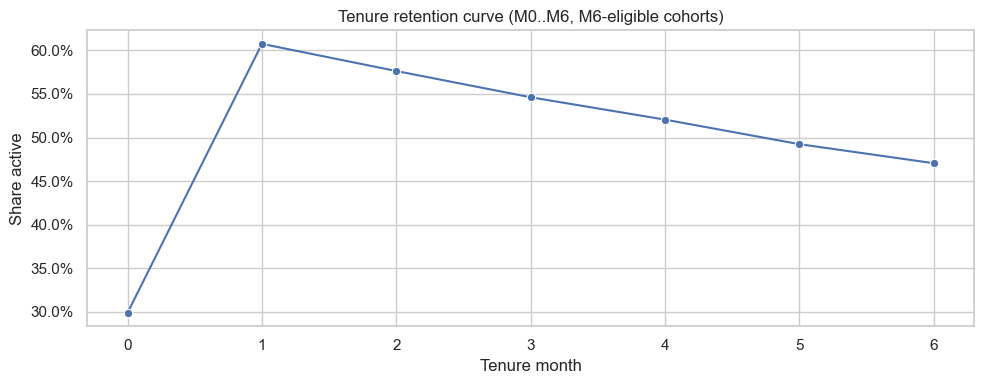

In [85]:

# Q3: tenure retention and drop-off on M6-eligible population
pivot_m6 = pivot[pivot["eligible_h6"]].copy()
retention_by_tenure = pd.DataFrame(
    {
        "tenure_month": list(range(7)),
        "retention_rate": [pivot_m6[f"m{i}"].mean() for i in range(7)],
    }
)
retention_by_tenure["drop_from_prev"] = retention_by_tenure["retention_rate"].shift(1) - retention_by_tenure[
    "retention_rate"
]

largest_drop_row = retention_by_tenure.loc[retention_by_tenure["drop_from_prev"].idxmax()]
print(
    f"Largest disengagement window: M{int(largest_drop_row['tenure_month']) - 1} -> M{int(largest_drop_row['tenure_month'])} "
    f"(drop={largest_drop_row['drop_from_prev']:.2%})"
)

display(retention_by_tenure)

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=retention_by_tenure, x="tenure_month", y="retention_rate", marker="o", ax=ax)
ax.set_title("Tenure retention curve (M0..M6, M6-eligible cohorts)")
ax.set_xlabel("Tenure month")
ax.set_ylabel("Share active")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xticks(range(7))
plt.tight_layout()
plt.show()


Users aren't finding the value immediately (M0), but those who survive the first month become highly engaged. This suggests that the onboarding process takes time or the product requires a setup period before it becomes useful.

We need to investigate what happens in M1 that doesn't happen in M0


<a id="bqn"></a>

### Cohort KPIs over time

We evaluate cohort quality with **M3** and **M6** active checkpoints plus strict streak variants (**M0..M3** and **M0..M6**). **M6** is the stronger quality test with this history, while **M3** remains an early leading indicator.

The second panel shows eligible denominator by horizon, so trend changes can be interpreted alongside sample support.

[↑ Back to summary](#summary)


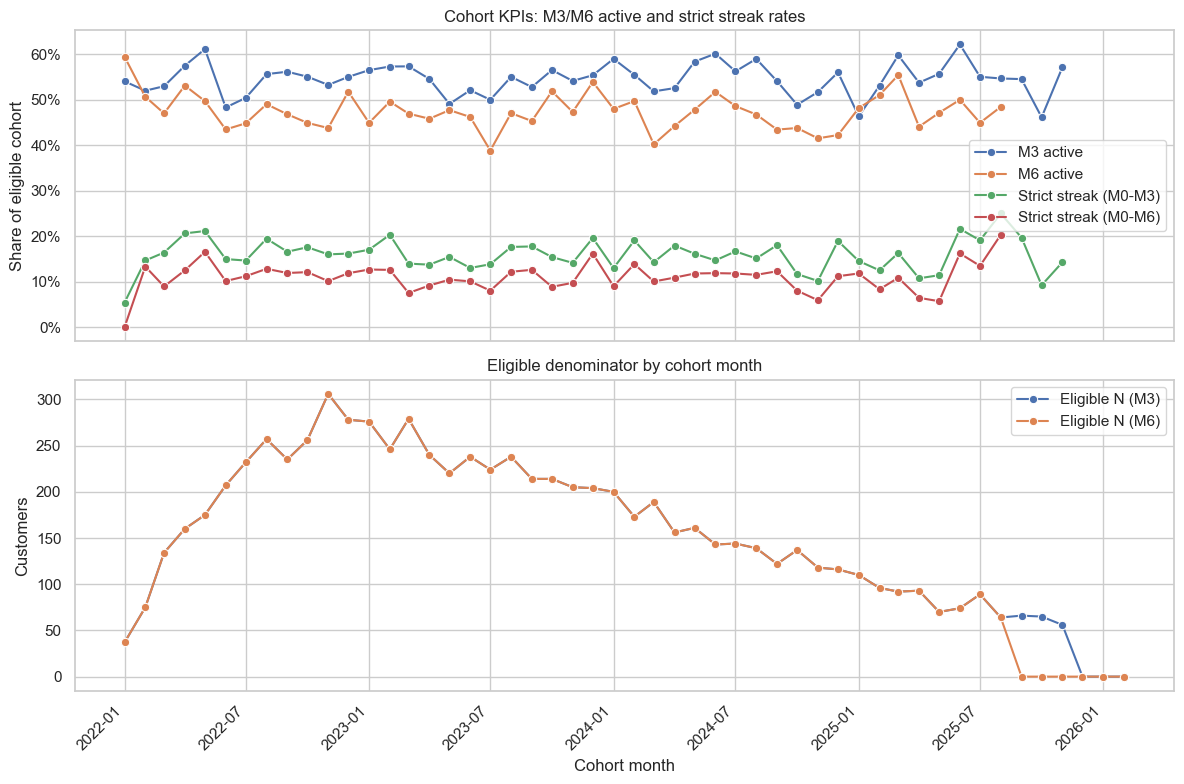

In [86]:

plot_kpi = cohort_kpi.sort_values("cohort_month").copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

kpi_long = plot_kpi.melt(
    id_vars=["cohort_month"],
    value_vars=["m3_active_rate", "m6_active_rate", "strict_streak_m3_rate", "strict_streak_m6_rate"],
    var_name="kpi",
    value_name="rate",
)
kpi_long["kpi"] = kpi_long["kpi"].map(
    {
        "m3_active_rate": "M3 active",
        "m6_active_rate": "M6 active",
        "strict_streak_m3_rate": "Strict streak (M0-M3)",
        "strict_streak_m6_rate": "Strict streak (M0-M6)",
    }
)

sns.lineplot(
    data=kpi_long,
    x="cohort_month",
    y="rate",
    hue="kpi",
    marker="o",
    ax=ax1,
)
ax1.set_title("Cohort KPIs: M3/M6 active and strict streak rates")
ax1.set_ylabel("Share of eligible cohort")
ax1.set_xlabel("")
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.legend(title=None, loc="best")

sns.lineplot(
    data=plot_kpi,
    x="cohort_month",
    y="eligible_n_h3",
    marker="o",
    label="Eligible N (M3)",
    ax=ax2,
)
sns.lineplot(
    data=plot_kpi,
    x="cohort_month",
    y="eligible_n_h6",
    marker="o",
    label="Eligible N (M6)",
    ax=ax2,
)
ax2.set_title("Eligible denominator by cohort month")
ax2.set_ylabel("Customers")
ax2.set_xlabel("Cohort month")
ax2.legend(title=None, loc="best")

for ax in (ax1, ax2):
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

fig.tight_layout()
plt.show()


While our total customer volume remained stable throughout 2024 and 2025 (averaging ~350 new customers/month), cohort quality has degraded sharply since Q2 2025. Recent cohorts are showing 20-25 percentage points lower retention at the M3 and M6 marks compared to our 2024 benchmarks. We need to investigate if this is due to a change in acquisition channel mix or a product friction point introduced in mid-2025.

So many users remain “active” by checkpoint (M3/M6) without being consistently active every month. **That pattern is normal in payments, but the widening fragility in newer cohorts suggests increased intermittency and potential habit decay.**


<a id="bq4"></a>

### Roadmap Q4 — Are recent cohorts healthier than older ones?

Looking at the chart above, recent cohorts look weaker, especially on M6 and strict M0–M6.

[↑ Back to summary](#summary)



<a id="bq5"></a>

#### KPIs by acquisition channel

Using the same roster and eligibility rules, we group by **`cohort_month`** and **`acquisition_channel`** and compute **M6 active rate** and **strict streak M0..M6** as primary quality metrics, with M3 as a secondary signal. The ranking table is weighted by eligible cohort size and ordered by M6 first, then M3.

[↑ Back to summary](#summary)


In [87]:

# Channel KPI table with horizon-specific denominators
ch_rows = []
for (cohort_month, channel), g in pivot.groupby(["cohort_month", "acquisition_channel"]):
    row = {"cohort_month": cohort_month, "acquisition_channel": channel}

    g3 = g[g["eligible_h3"]]
    row["eligible_n_h3"] = int(len(g3))
    row["m3_active_count"] = int(g3["m3"].sum())
    row["strict_streak_m3_count"] = int(g3["strict_streak_m3"].sum())
    row["m3_active_rate"] = row["m3_active_count"] / row["eligible_n_h3"] if row["eligible_n_h3"] else np.nan
    row["strict_streak_m3_rate"] = (
        row["strict_streak_m3_count"] / row["eligible_n_h3"] if row["eligible_n_h3"] else np.nan
    )

    g6 = g[g["eligible_h6"]]
    row["eligible_n_h6"] = int(len(g6))
    row["m6_active_count"] = int(g6["m6"].sum())
    row["strict_streak_m6_count"] = int(g6["strict_streak_m6"].sum())
    row["m6_active_rate"] = row["m6_active_count"] / row["eligible_n_h6"] if row["eligible_n_h6"] else np.nan
    row["strict_streak_m6_rate"] = (
        row["strict_streak_m6_count"] / row["eligible_n_h6"] if row["eligible_n_h6"] else np.nan
    )

    ch_rows.append(row)

channel_kpi = pd.DataFrame(ch_rows).sort_values(["cohort_month", "acquisition_channel"]).reset_index(drop=True)

# Q5 helper ranking: M6-first quality ranking by channel
channel_rank = (
    channel_kpi.dropna(subset=["m6_active_rate"])
    .groupby("acquisition_channel")
    .apply(
        lambda g: pd.Series(
            {
                "eligible_n_h6": g["eligible_n_h6"].sum(),
                "m6_active_rate_weighted": np.average(g["m6_active_rate"], weights=g["eligible_n_h6"]),
                "m3_active_rate_weighted": np.average(g["m3_active_rate"], weights=g["eligible_n_h3"]),
            }
        )
    )
    .reset_index()
    .sort_values(["m6_active_rate_weighted", "m3_active_rate_weighted"], ascending=False)
)

display(channel_kpi.tail(10))
print("Channel quality ranking (M6 primary, M3 secondary)")
display(channel_rank)


,cohort_month,acquisition_channel,eligible_n_h3,m3_active_count,strict_streak_m3_count,m3_active_rate,strict_streak_m3_rate,eligible_n_h6,m6_active_count,strict_streak_m6_count,m6_active_rate,strict_streak_m6_rate
190,2025-12-01,partnership,0,0,0,NaN,NaN,0,0,0,NaN,NaN
191,2025-12-01,referral,0,0,0,NaN,NaN,0,0,0,NaN,NaN
192,2026-01-01,organic,0,0,0,NaN,NaN,0,0,0,NaN,NaN
193,2026-01-01,paid_ads,0,0,0,NaN,NaN,0,0,0,NaN,NaN
194,2026-01-01,partnership,0,0,0,NaN,NaN,0,0,0,NaN,NaN
195,2026-01-01,referral,0,0,0,NaN,NaN,0,0,0,NaN,NaN
196,2026-02-01,organic,0,0,0,NaN,NaN,0,0,0,NaN,NaN
197,2026-02-01,paid_ads,0,0,0,NaN,NaN,0,0,0,NaN,NaN
198,2026-02-01,partnership,0,0,0,NaN,NaN,0,0,0,NaN,NaN
199,2026-02-01,referral,0,0,0,NaN,NaN,0,0,0,NaN,NaN


Channel quality ranking (M6 primary, M3 secondary)


,acquisition_channel,eligible_n_h6,m6_active_rate_weighted,m3_active_rate_weighted
3,referral,1828.0,0.662473,0.719365
2,partnership,1896.0,0.497363,0.577532
0,organic,1919.0,0.430433,0.514851
1,paid_ads,1993.0,0.307577,0.387858


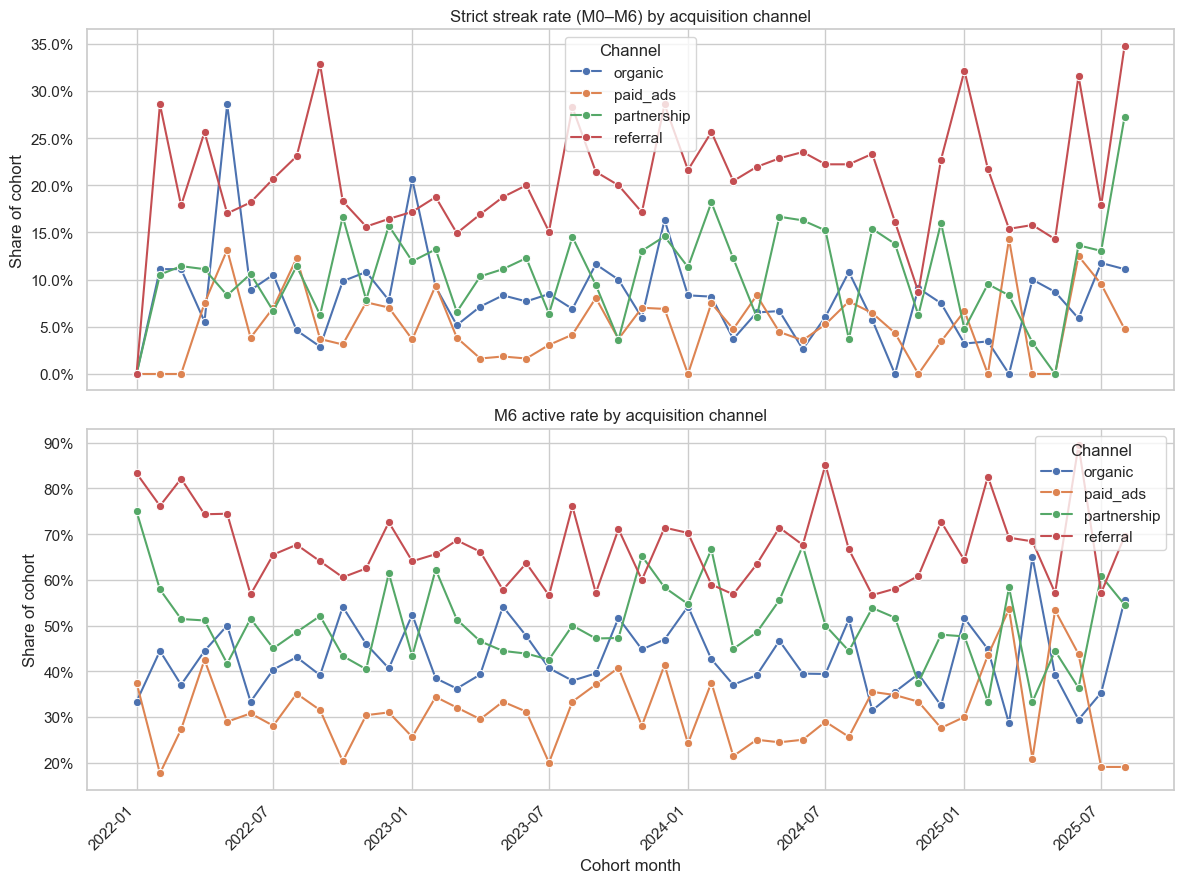

In [88]:

plot_ch = channel_kpi.sort_values(["cohort_month", "acquisition_channel"]).copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

sns.lineplot(
    data=plot_ch,
    x="cohort_month",
    y="strict_streak_m6_rate",
    hue="acquisition_channel",
    marker="o",
    ax=ax1,
)
ax1.set_title("Strict streak rate (M0–M6) by acquisition channel")
ax1.set_ylabel("Share of cohort")
ax1.set_xlabel("")
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.legend(title="Channel", loc="best")

sns.lineplot(
    data=plot_ch,
    x="cohort_month",
    y="m6_active_rate",
    hue="acquisition_channel",
    marker="o",
    ax=ax2,
)
ax2.set_title("M6 active rate by acquisition channel")
ax2.set_ylabel("Share of cohort")
ax2.set_xlabel("Cohort month")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.legend(title="Channel", loc="best")

for ax in (ax1, ax2):
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

fig.tight_layout()
plt.show()


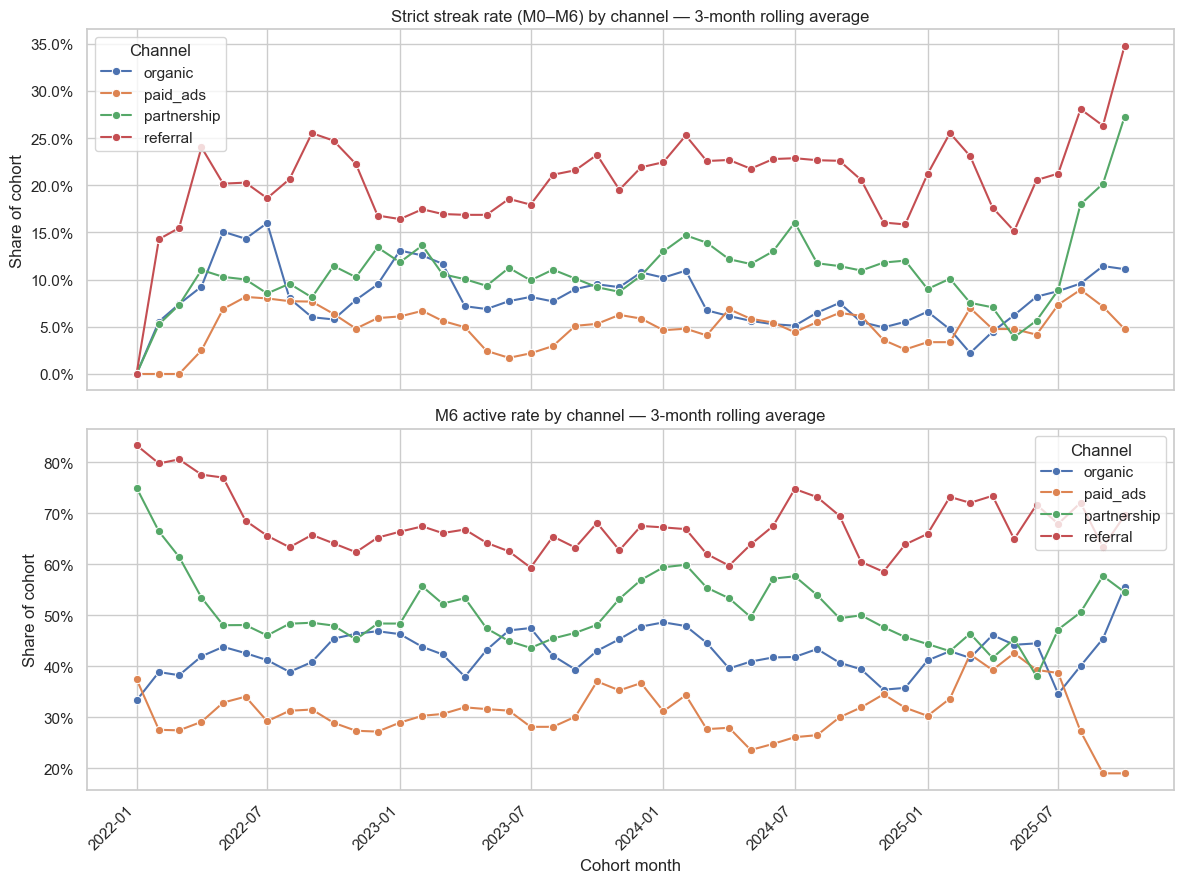

In [89]:

# Rolling average of channel cohort rates (reduces month-to-month noise)
ROLLING_MONTHS = 3

smooth_ch = plot_ch.sort_values(["acquisition_channel", "cohort_month"]).copy()
smooth_ch["strict_streak_m6_roll"] = smooth_ch.groupby("acquisition_channel")[
    "strict_streak_m6_rate"
].transform(lambda s: s.rolling(ROLLING_MONTHS, min_periods=1).mean())
smooth_ch["m6_active_roll"] = smooth_ch.groupby("acquisition_channel")[
    "m6_active_rate"
].transform(lambda s: s.rolling(ROLLING_MONTHS, min_periods=1).mean())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

sns.lineplot(
    data=smooth_ch,
    x="cohort_month",
    y="strict_streak_m6_roll",
    hue="acquisition_channel",
    marker="o",
    ax=ax1,
)
ax1.set_title(
    f"Strict streak rate (M0–M6) by channel — {ROLLING_MONTHS}-month rolling average"
)
ax1.set_ylabel("Share of cohort")
ax1.set_xlabel("")
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.legend(title="Channel", loc="best")

sns.lineplot(
    data=smooth_ch,
    x="cohort_month",
    y="m6_active_roll",
    hue="acquisition_channel",
    marker="o",
    ax=ax2,
)
ax2.set_title(f"M6 active rate by channel — {ROLLING_MONTHS}-month rolling average")
ax2.set_ylabel("Share of cohort")
ax2.set_xlabel("Cohort month")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.legend(title="Channel", loc="best")

for ax in (ax1, ax2):
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

fig.tight_layout()
plt.show()


Our overall retention decline is primarily driven by a sharp degradation in Paid Ads quality. While this channel previously delivered our highest-LTV (Lifetime Value) users, cohorts acquired via ads since March 2025 are churning at twice the historical rate. Conversely, Referral remains our most resilient channel. Recommendation: Immediate audit of ad creative and targeting; reallocate 20%-30% of the Paid budget to Referral incentives to stabilize the M6 retention floor.


<a id="notebook2-closing"></a>

## Notebook summary — business questions & what comes next

[↑ Back to summary](#summary)

### Business questions answered (this notebook)

**Q2 — Which acquisition month produces the most retained customers?**  
After you run the notebook, use the printed tables:
- **Top cohort months by M6 retention rate** (quality): March 2024
- **Top cohort months by retained users at M6** (volume): March 2024

**Q3 — At what month do most customers disengage?**  
M4->M5 shows the steepest drop. Re-engagement campaign at M4 could revert this trend.
Also, the retention retention curve is showing us that out onboarding process isn't fast or good enough, because there is a "jump" between M0 and M1.
 
**Q4 — Are recent cohorts healthier than older ones?**  
No, the widening gap in recent months suggests that not only is retention dropping, but consistency is also failing. We are losing the "habit-forming" nature of the product.

**Q5 — Which acquisition channel brings the highest quality customers?**  
Referral.
Referral users have "social proof." They stay longer and are more consistent. We should shift budget from Paid Ads toward a Referral Program or "Member-get-Member" incentives.

Also, starting around 2025-03, Paid Ads performance plummeted. By the end of the chart, it is your worst-performing channel, with M6 active rates crashing toward 35%.

---

**What we established (concise)**

- **Calendar-time behavior** — Volume, **TPV**, and **MAU** scale through the window; stacked **channel** views show **digital-led** growth (**in_app** dominant).
- **Reusable monthly grain** — **`df_tx`** supports per-customer, per-month aggregates for downstream notebooks.
- **Cohort retention quality (M3 + M6)** — **Full customer roster** + completed **tx** grid yields active and strict-streak metrics across two horizons; M6 gives a stronger quality signal while M3 remains an early indicator.

**Where the pipeline goes next**

| Next step | Notebook | How it builds on this work |
|-----------|--------------------------------------------|----------------------------|
| Deeper cohort views (done here) | **Notebook 2** — Transactions EDA & cohorts | This notebook now covers the **M3 + M6** cohort KPIs, a tenure retention curve (`M0..M6`), and channel-quality ranking—i.e., the core “Notebook 3” cohort outcomes are already implemented here. |
| Behavioral segments | **Notebook 3** — RFM & clustering | Consume the monthly and recency-style aggregates from here to score **Recency, Frequency, Monetary** and form segments. |
| Economics | **Notebook 4** — Unit economics | Combine acquisition fields from customers with revenue aggregates from transactions for LTV, CAC, and payback. |
| Churn modeling | **Notebook 5** — Logistic regression | Use cohort, RFM, and engagement features together to define churn labels and train a probability model. |

This notebook ties **how customers transact in calendar time** to **cohort retention behavior through M6**; later notebooks add **RFM**, **unit economics**, and **predictive churn**.

---
